# Visión por Computadora II - 2025 - B4 - Trabajo práctico integrador
**Inteligencia Artificial - CEIA - FIUBA**

## Autores

- **Mendoza Dante**.

- **Vasquez Jorge**.

- **Viñas Gustavo**.

**Dataset elegido:** https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset

**Descripcion:** Detección de enfermedades en cultivos agrícolas. Entrenar un modelo que identifique y clasifique enfermedades en plantas a partir de imágenes, ayudando a los agricultores a tomar medidas preventivas y reducir pérdidas.​

**Enfoque:** Entrenar un modelo para identificar una enfermedad específica en una especie de planta utilizando imágenes.​

# 💻 Montaje de entorno y definición de rutas

- Definir entorno de proyecto.

- Visualizar las rutas del dataset.

In [1]:
%pip install --quiet pandas matplotlib scikit-learn torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import os
from zipfile import ZipFile

# Funcion auxiliar para descargar el dataset
def download_dataset(target_dir, subset: str | None = None, force: bool = False):
    dataset_url = "https://www.kaggle.com/api/v1/datasets/download/abdallahalidev/plantvillage-dataset"
    dataset_folder = "plantvillage dataset"
    tmp_file = "tmp.zip"

    if not(subset is None or subset.lower() in ["color", "grayscale", "segmented"]):
        raise Exception("subset debe ser None, color, grayscale o segmented")

    if os.path.isdir(target_dir) and not force:
        if subset is None:
            print("Dataset folder already exists, nothing downloaded.")
            return
        if os.path.isdir(os.path.join(target_dir, subset)):
            print(f"Folder already exists for subset \"{subset}\", nothing downloaded.")
            return

    try:
        with requests.get(dataset_url, stream=True) as response:
            response.raise_for_status()  # Raise an exception for bad status codes

            with open(tmp_file, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
        print(f"File '{tmp_file}' downloaded successfully.")
    except requests.exceptions.RequestException as e:
        if (os.path.isfile(tmp_file)):
            os.remove(tmp_file)
        raise(Exception(f"Error downloading file: {e}"))

    try:
        with ZipFile(tmp_file, 'r') as zip_object:
            for member in zip_object.infolist():
                if member.filename.startswith(dataset_folder):
                    member.filename = member.filename[len(dataset_folder)+1:]
                    if subset is None or member.filename.startswith(subset):
                        zip_object.extract(member, target_dir)
        print(f"Successfully extracted '{tmp_file}' to '{target_dir}' for " + ('all subsets' if subset is None else f"{subset} subset") + ".")

    except FileNotFoundError:
        raise(Exception(f"Error: The file '{tmp_file}' was not found."))
    except Exception as e:
        raise(Exception(f"An error occurred: {e}"))
    finally:
        if (os.path.isfile(tmp_file)):
            os.remove(tmp_file)


In [3]:
# ====================================================
# MONTAJE DE ENTORNO Y DEFINICIÓN DE RUTAS
# ====================================================

# Descargamos el dataset si no existe la carpeta
base_dir = "datasets"
subset = "color"
download_dataset(base_dir, subset)


# Ruta al dataset
DATASET_PATH = os.path.join(base_dir, subset)

print("Ruta del dataset:", DATASET_PATH)
print("Listado de carpetas:", os.listdir(DATASET_PATH)[:10])

Folder already exists for subset "color", nothing downloaded.
Ruta del dataset: datasets\color
Listado de carpetas: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy']


# 💻 Preparamos el dataset (split + DataLoader)

- Vamos a tomar todas las clases.

- Creamos carpetas train/val/test con split 70/15/15.

- Definimos DataLoader en PyTorch con transformaciones (resize, normalización, data augmentation).

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset

class TransformationDataset(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __getitem__(self, index):
        if self.transform:
            x = self.transform(self.dataset[index][0])
        else:
            x = self.dataset[index][0]
        y = self.dataset[index][1]
        return x, y

    def __len__(self):
        return len(self.dataset)

In [5]:
import random
from collections import Counter
import numpy as np
from torch.utils.data import WeightedRandomSampler
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

batch_size = 128 # Definimos 128, ya que al ser 38 clases, 32 o 64 no es suficiente para tener al menos una muestra de cada clase en cada batch
img_size = (224,224) # Tamaño mínimo para modelos preentrenados, utilizamos el mismo tamaño para nuestro modelo

full_dataset = datasets.ImageFolder(DATASET_PATH)

targets = [s[1] for s in full_dataset.samples] # Descomentar si se quiere usar todo el dataset
# targets = [s[1] for s in random.sample(full_dataset.samples, 10000)] # Descomentar si se quiere usar solo una muestra del dataset

# Usamos train_test_split para hacer splits estratificados que conserven la distribución de clases
train_idx, test_idx = train_test_split(np.arange(len(targets)), test_size=0.2, stratify=targets, random_state=42)
train_idx, val_idx = train_test_split(train_idx, test_size=0.25, stratify=np.array(targets)[train_idx], random_state=42) # 0.25 of 0.8 is 0.2

train_dataset = Subset(full_dataset, train_idx) # 0.6
val_dataset = Subset(full_dataset, val_idx)     # 0.2
test_dataset = Subset(full_dataset, test_idx)    # 0.2

transform_train = transforms.Compose([
    # Creamos variantes de las imagenes para evitar overfitting al hacer oversampling
    transforms.RandomCrop(img_size), # En train hacemos random crop a img_size
    transforms.RandomRotation(15), # En train hacemos rotaciones aleatorias de hasta 15 grados
    transforms.RandomHorizontalFlip(), # En train hacemos flip horizontal aleatorio
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Variaciones de brillo y contraste. No hacemos variaciones de color para no perder info de la hoja y enfermedades.
    transforms.ToTensor(), # Escala entre 0 y 1; pasa a tensor; poner canales en 1ra dim
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

transform_val_test = transforms.Compose([
    transforms.CenterCrop(img_size), # En validación y test hacemos center crop a img_size
    transforms.ToTensor(),# Escala entre 0 y 1; pasa a tensor; poner canal en 1ra dim
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

# Calculo pesos de las clases para balancear el dataset de entrenamiento
class_counts = Counter(np.array(targets)[train_idx])
num_samples = sum(class_counts.values())
class_weights = {cls: num_samples / count for cls, count in class_counts.items()}
sample_weights = [class_weights[target] for target in np.array(targets)[train_idx]]

# Balanceo de clases en entrenamiento usando WeightedRandomSampler.
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_dataloader = DataLoader(TransformationDataset(train_dataset, transform_train), batch_size=batch_size, pin_memory=True, sampler=sampler)
val_dataloader = DataLoader(TransformationDataset(val_dataset, transform_val_test), batch_size=batch_size, shuffle=False, pin_memory=True)
test_dataloader = DataLoader(TransformationDataset(test_dataset, transform_val_test), batch_size=batch_size, shuffle=False, pin_memory=True)


In [6]:
print("Distribucion de muestras:")
print("\nFull: ", len(full_dataset), "\nTrain:", len(train_dataset), "\nVal:", len(val_dataset), "\nTest:", len(test_dataset))
print(f"\nNúmero de clases totales: {len(full_dataset.classes)}.")

Distribucion de muestras:

Full:  54305 
Train: 32583 
Val: 10861 
Test: 10861

Número de clases totales: 38.


In [7]:
print("Clases -> ids:")
idx_to_class = {v: i for i,v in full_dataset.class_to_idx.items()}
print(full_dataset.class_to_idx)
print("Ids -> clases:")
print(idx_to_class)

Clases -> ids:
{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_bligh

In [8]:
# Cargamos un batch del dataloader para probar que todo este ok
train_features, train_labels = next(iter(train_dataloader))
len(train_features), len(train_labels)

(128, 128)

In [9]:
# verificamos sus dimensiones
print(f"Tamaño del batch de feature (input / imagen): {train_features.size()}")
print(f"Tamaño del batch del label (clase / etiqueta): {train_labels.size()}")

Tamaño del batch de feature (input / imagen): torch.Size([128, 3, 224, 224])
Tamaño del batch del label (clase / etiqueta): torch.Size([128])


tamaño de 1 imagen:  torch.Size([1, 3, 224, 224])
tamaño de 1 imagen DESPUES de squeeze:  torch.Size([224, 224, 3])


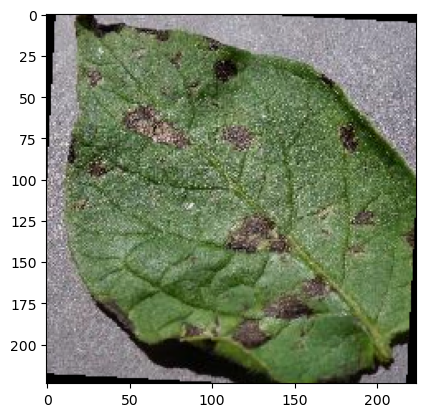

Label: 20 (Potato___Early_blight)


In [10]:
import torch
import matplotlib.pyplot as plt

# tomamos 1 imagen para poder visualizarla y verificar sus dimensiones
img_idx = torch.randint(len(train_features), (1,))
img = train_features[img_idx]
print('tamaño de 1 imagen: ', img.shape)
# le quitamos 1 dimension (la del tamaño del batch) y reordenamos para poder graficar
img = img.squeeze().permute(1, 2, 0)
print('tamaño de 1 imagen DESPUES de squeeze: ', img.shape)
label = train_labels[img_idx]

# Unnormalize
img = np.array([0.229, 0.224, 0.225]) * img.numpy() + np.array([0.485, 0.456, 0.406])
img = np.clip(img, 0, 1) # Clip values to be between 0 and 1

# ploteo esa imagen
plt.imshow(img)
plt.show()
print(f"Label: {label.item()} ({idx_to_class[label.item()]})")

# 💻 Modelo AlexNet

- Para este modelo utilizaremos la arquitectura AlexNet preentrenada con IMAGENET1K_V1.  
  Haremos pruebas reemplazando solo la última capa FC, y luego todas las FC, para entrenar con nuestro set de datos.  
  Estas pruebas se realizarán congelando los hiperparámetros de AlexNet previo al reemplazo de capas (feature extraction).  
  En la que funcione mejor, también probaremos sin congelar los hiperparámetros (fine tuning).


Creamos una clase para guardar métricas (y luego graficar).

In [11]:
# A simple metric tracker
class MetricTracker:
    def __init__(self):
        self.metrics = {}

    def update(self, metric_name, value):
        if metric_name not in self.metrics:
            self.metrics[metric_name] = []
        self.metrics[metric_name].append(value)

    def get_latest(self, metric_name):
        if metric_name in self.metrics and self.metrics[metric_name]:
            return self.metrics[metric_name][-1]
        return None

    def get_all(self, metric_name):
        return self.metrics.get(metric_name, [])

    def reset(self):
        self.metrics = {}

    def plot_metrics(self, metric_names=None, figsize=(12, 6)):
        """Plot training metrics"""
        if metric_names is None:
            metric_names = list(self.metrics.keys())

        plt.figure(figsize=figsize)
        for metric_name in metric_names:
            values = self.get_all(metric_name)
            if values:
                plt.plot(values, label=metric_name)

        plt.title('Training Metrics')
        plt.xlabel('Epocs')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

Seleccionamos el dispositivo donde se ejecutará el entrenamiento

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Creamos la función de entrenamiento

In [13]:
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

# función de entrenamiento
def fit(model, dataloader, criterion, optimizer, scheduler, epochs=15, patience=3, patience_factor=0.01, model_file = 'best_model.pt'):
    # Metricas para graficar evolución por épocas
    metric_tracker = MetricTracker()
    best_model = 0
    # Set metric for callbacks
    best_eval = 0
    pt_epoch = 0
    best_eval_epoch_y = []
    best_eval_epoch_y_pred = []

    # enviamos el modelo al device
    model.to(device)
    # iteramos en las epocas
    for epoch in range(1, epochs+1):
        # ponemos el modelo en train
        model.train()
        train_loss = 0.0
        epoch_y_hat = []
        epoch_y = []
        bar = tqdm(dataloader['train'])
        for i, batch in enumerate(bar):
            X, y = batch  # sacamos X e y del batch
            X, y = X.to(device), y.to(device) # lo enviamos al device
            optimizer.zero_grad() # llevamos optimizer a zero
            y_hat = model(X)  # corremos el modelo y vemos su predicción
            loss = criterion(y_hat, y)  # calculamos la pérdida
            loss.backward() # back-propagations
            optimizer.step()  # step del optimizer

            # Almaceno los valores reales y mis predicciones para cálcular las métricas
            epoch_y += list(y.detach().cpu().numpy())
            epoch_y_hat += list(y_hat.detach().cpu().numpy())

            # Track loss for this batch
            train_loss += loss.item()

            # cálculo de acc
            acc = accuracy_score(epoch_y, np.argmax(epoch_y_hat, axis=1))
            # seteamos descriptores en la barra
            bar.set_description(f"loss {train_loss/(i+1):.5f} acc {acc:.5f}")

            # Step-level callback
            scheduler.step()

        # Cálculo la métrica de la epoch
        # Compute training metrics
        train_loss /= len(bar)
        train_preds_classes = np.argmax(epoch_y_hat, axis=1)
        train_accuracy = accuracy_score(epoch_y, train_preds_classes)
        train_f1 = f1_score(epoch_y, train_preds_classes, average='macro')

        metric_tracker.update("train_loss", train_loss)
        metric_tracker.update("train_accuracy", train_accuracy)
        metric_tracker.update("train_f1", train_f1)

        # ahora evaluamos test
        eval_loss = 0.0
        valid_epoch_y_hat = []
        valid_epoch_y = []
        # ponemos en eval el modelo
        model.eval()
        bar = tqdm(dataloader['val'])
        with torch.no_grad():
            for i, batch in enumerate(bar):
                X, y = batch
                X, y = X.to(device), y.to(device)
                y_hat = model(X)
                loss = criterion(y_hat, y)

                eval_loss += loss.item()
                # Almaceno los valores reales y mis predicciones para cálcular las métricas
                valid_epoch_y += list(y.detach().cpu().numpy())
                valid_epoch_y_hat += list(y_hat.detach().cpu().numpy())
                # calculo de la acc
                val_acc = accuracy_score(valid_epoch_y, np.argmax(valid_epoch_y_hat, axis=1))

                bar.set_description(f"val_loss {eval_loss/(i+1):.5f} val_acc {val_acc:.5f}")

        # Cálculo la métrica de la epoch
        # Compute evaluation metrics
        eval_loss /= len(bar)
        eval_preds_classes = np.argmax(valid_epoch_y_hat, axis=1)
        eval_accuracy = accuracy_score(valid_epoch_y, eval_preds_classes)
        eval_f1 = f1_score(valid_epoch_y, eval_preds_classes, average='macro')

        metric_tracker.update("eval_loss", eval_loss)
        metric_tracker.update("eval_accuracy", eval_accuracy)
        metric_tracker.update("eval_f1", eval_f1)

        print(f"Epoch {epoch}/{epochs} loss {train_loss:.5f} val_loss {eval_loss:.5f} acc {train_accuracy:.5f} val_acc {eval_accuracy:.5f}")

        if eval_accuracy>best_model:
            # Guardo el mejor modelo
            torch.save(model.state_dict(), model_file)
            best_model = eval_accuracy
            best_eval_epoch_y = valid_epoch_y
            best_eval_epoch_y_pred = eval_preds_classes
        ## Early stopping
        if eval_accuracy>=best_eval*(1+patience_factor):
            best_eval = eval_accuracy
            pt_epoch = 0
        else:
            pt_epoch += 1
            if pt_epoch>=patience:
                print(f"\tInfo - Training interrupted due to early stopping condition.")
                break
            else:
                print(f"\tInfo - Current epochs without validation metric improvement {pt_epoch}. {patience-pt_epoch} remaining before stopping.")

    return  metric_tracker, best_eval_epoch_y, best_eval_epoch_y_pred

Creamos visualización para matriz de confusión

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_cm(y_true, y_pred):
    class_labels = list(idx_to_class.values())
    fig = plt.figure(figsize=(30,10))
    # Matriz de confusión absoluta
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    ax=fig.add_subplot(121)
    ax.grid(False)
    disp.plot(ax=ax, values_format='d', xticks_rotation=90)

### Descargamos yu modificamos el modelo AlexNet

In [15]:
dset_classes_number = len(train_dataset.dataset.class_to_idx)
print(f"Número de clases en el dataset: {dset_classes_number}")

Número de clases en el dataset: 38


In [16]:
from torchvision import models
from torchvision.models.alexnet import AlexNet_Weights

# Load the pre-trained AlexNet model
model_alexnet_fe = models.alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)

# Características del modelo preentrenado

# All pre-trained models expect input images normalized in the same way, 
# i.e. mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be at least 224. 
# The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225].


In [17]:
# Verificamos la arquitectura del modelo antes de hacerle transfer learning
import torchinfo as torchinfo
torchinfo.summary(model_alexnet_fe, input_size=(batch_size, 3, *img_size))

Layer (type:depth-idx)                   Output Shape              Param #
AlexNet                                  [128, 1000]               --
├─Sequential: 1-1                        [128, 256, 6, 6]          --
│    └─Conv2d: 2-1                       [128, 64, 55, 55]         23,296
│    └─ReLU: 2-2                         [128, 64, 55, 55]         --
│    └─MaxPool2d: 2-3                    [128, 64, 27, 27]         --
│    └─Conv2d: 2-4                       [128, 192, 27, 27]        307,392
│    └─ReLU: 2-5                         [128, 192, 27, 27]        --
│    └─MaxPool2d: 2-6                    [128, 192, 13, 13]        --
│    └─Conv2d: 2-7                       [128, 384, 13, 13]        663,936
│    └─ReLU: 2-8                         [128, 384, 13, 13]        --
│    └─Conv2d: 2-9                       [128, 256, 13, 13]        884,992
│    └─ReLU: 2-10                        [128, 256, 13, 13]        --
│    └─Conv2d: 2-11                      [128, 256, 13, 13]       

#### Modelo AlexNet - prueba 1
Ajustamos el modelo a nuestro problema por resolver, reemplazando solo la última capa FC

In [18]:
from torch import nn

for param in model_alexnet_fe.parameters():
    param.requires_grad = False

num_in_class_ftrs = model_alexnet_fe.classifier[-1].in_features 
model_alexnet_fe.classifier[-1] = nn.Linear(4096, dset_classes_number)

In [19]:
# Verificamos la arquitectura del modelo luego de los cambios
# La diferencia se observa en la última capa que ahora tiene el número de clases del dataset
# De esta forma, tenemos que reentrenaremos la capa de clasificación.
torchinfo.summary(model_alexnet_fe, input_size=(batch_size, 3, *img_size))

Layer (type:depth-idx)                   Output Shape              Param #
AlexNet                                  [128, 38]                 --
├─Sequential: 1-1                        [128, 256, 6, 6]          --
│    └─Conv2d: 2-1                       [128, 64, 55, 55]         (23,296)
│    └─ReLU: 2-2                         [128, 64, 55, 55]         --
│    └─MaxPool2d: 2-3                    [128, 64, 27, 27]         --
│    └─Conv2d: 2-4                       [128, 192, 27, 27]        (307,392)
│    └─ReLU: 2-5                         [128, 192, 27, 27]        --
│    └─MaxPool2d: 2-6                    [128, 192, 13, 13]        --
│    └─Conv2d: 2-7                       [128, 384, 13, 13]        (663,936)
│    └─ReLU: 2-8                         [128, 384, 13, 13]        --
│    └─Conv2d: 2-9                       [128, 256, 13, 13]        (884,992)
│    └─ReLU: 2-10                        [128, 256, 13, 13]        --
│    └─Conv2d: 2-11                      [128, 256, 13, 13

In [20]:
dataloader = { 'train': train_dataloader, 'val': val_dataloader }
steps_per_epoch = len(train_dataloader)

# Definimos optimizer y la función de pérdida
optimizer = torch.optim.Adam(model_alexnet_fe.parameters(), lr=0.001, weight_decay = 0.001)  
criterion = torch.nn.CrossEntropyLoss() # Adecuada para problemas de clasificación multiclase
# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=steps_per_epoch, T_mult=2, eta_min=1e-5)

In [21]:
model_name = "best_AlexNet_fe.pt"
metrics_alexnet_fe, alexnet_fe_eval_y, alexnet_fe_eval_y_pred = fit(model_alexnet_fe, dataloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, 
                                                                    epochs=15, patience=5, patience_factor=0.01, model_file=model_name)
# Al finalizar, cargo el mejor modelo
model_alexnet_fe.load_state_dict(torch.load(model_name))

val_loss 0.35908 val_acc 0.89412: 100%|██████████| 85/85 [00:16<00:00,  5.11it/s]


Epoch 1/15 loss 0.80226 val_loss 0.35908 acc 0.76868 val_acc 0.89412


val_loss 0.27427 val_acc 0.91603: 100%|██████████| 85/85 [00:16<00:00,  5.12it/s]


Epoch 2/15 loss 0.55239 val_loss 0.27427 acc 0.82678 val_acc 0.91603


val_loss 0.24186 val_acc 0.92607: 100%|██████████| 85/85 [00:16<00:00,  5.11it/s]


...

val_loss 0.20321 val_acc 0.93288: 100%|██████████| 85/85 [00:15<00:00,  5.37it/s]


Epoch 10/15 loss 0.40385 val_loss 0.20321 acc 0.86738 val_acc 0.93288
	Info - Current epochs without validation metric improvement 4. 1 remaining before stopping.


val_loss 0.18777 val_acc 0.93840: 100%|██████████| 85/85 [00:15<00:00,  5.34it/s]


Epoch 11/15 loss 0.39702 val_loss 0.18777 acc 0.86981 val_acc 0.93840
	Info - Training interrupted due to early stopping condition.


<All keys matched successfully>

En el entrenamiento vemos que el modelo llega a un accuracy de 0.94 aprox, en tan solo 7 épocas (más 5 de paciencia).  
Termina cortando por no tener mejora mayor al 1%, sin agotar todas las épocas.  
Esto es ligeramente peor que nuestro modelo base (0.96), pero lo consigue en menos épocas.

#### Evaluación del Modelo AlexNet con Feature Extraction reemplazando solo la última capa
  * Accuracy
  * F1 Score
  * Costo (Loss)
  * Classification report
  * Matriz de confusión


Valor final accuracy en set de validación: 0.938. Mejor valor: 0.941.


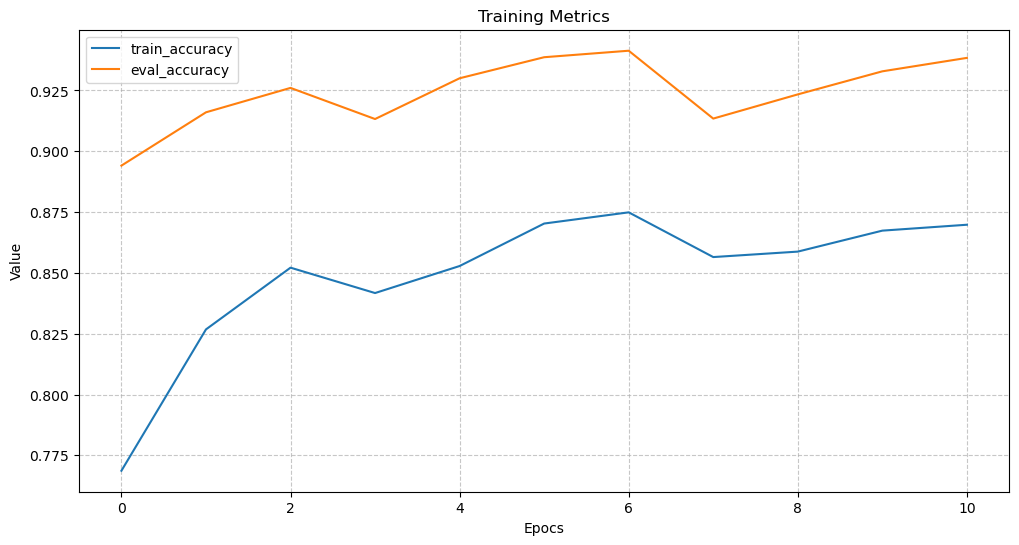

Valor final F1 en set de validación: 0.92


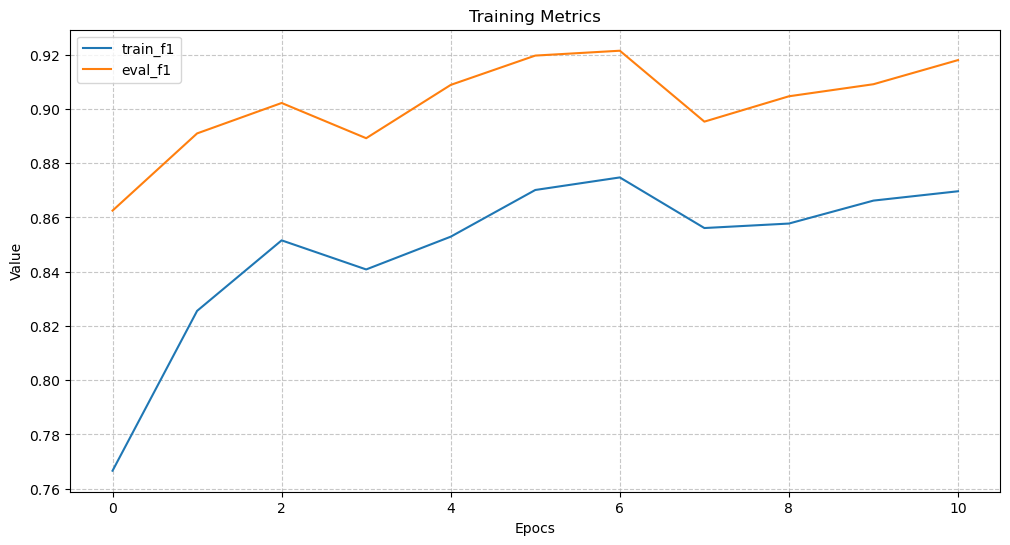

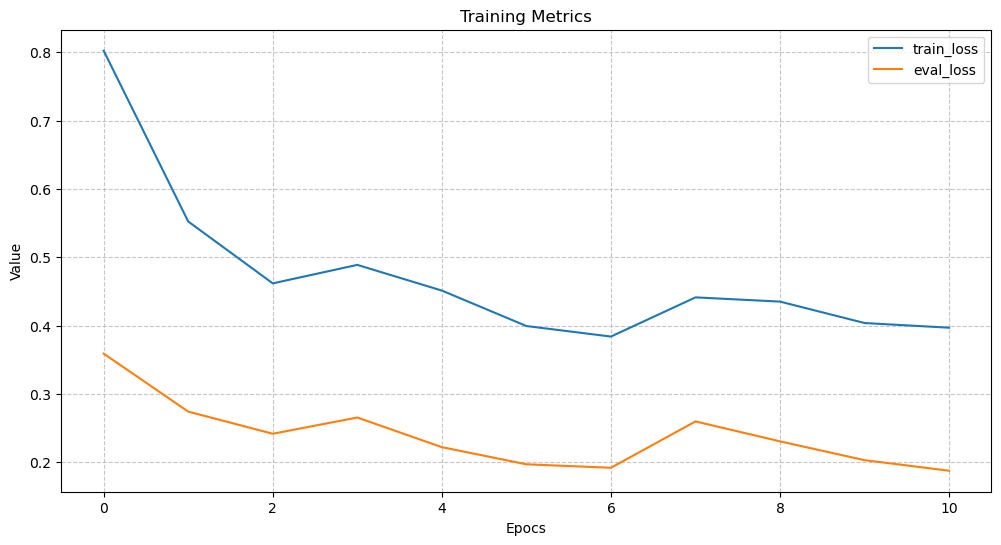

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.84      0.90      0.87       126
                                 Apple___Black_rot       0.92      0.98      0.95       124
                          Apple___Cedar_apple_rust       0.93      0.95      0.94        55
                                   Apple___healthy       0.97      0.91      0.94       329
                               Blueberry___healthy       0.98      0.99      0.98       300
          Cherry_(including_sour)___Powdery_mildew       0.99      0.97      0.98       210
                 Cherry_(including_sour)___healthy       0.96      0.98      0.97       171
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.80      0.83      0.81       103
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       238
               Corn_(maize)___Northern_Leaf_Blight       0.91      0.89      0.

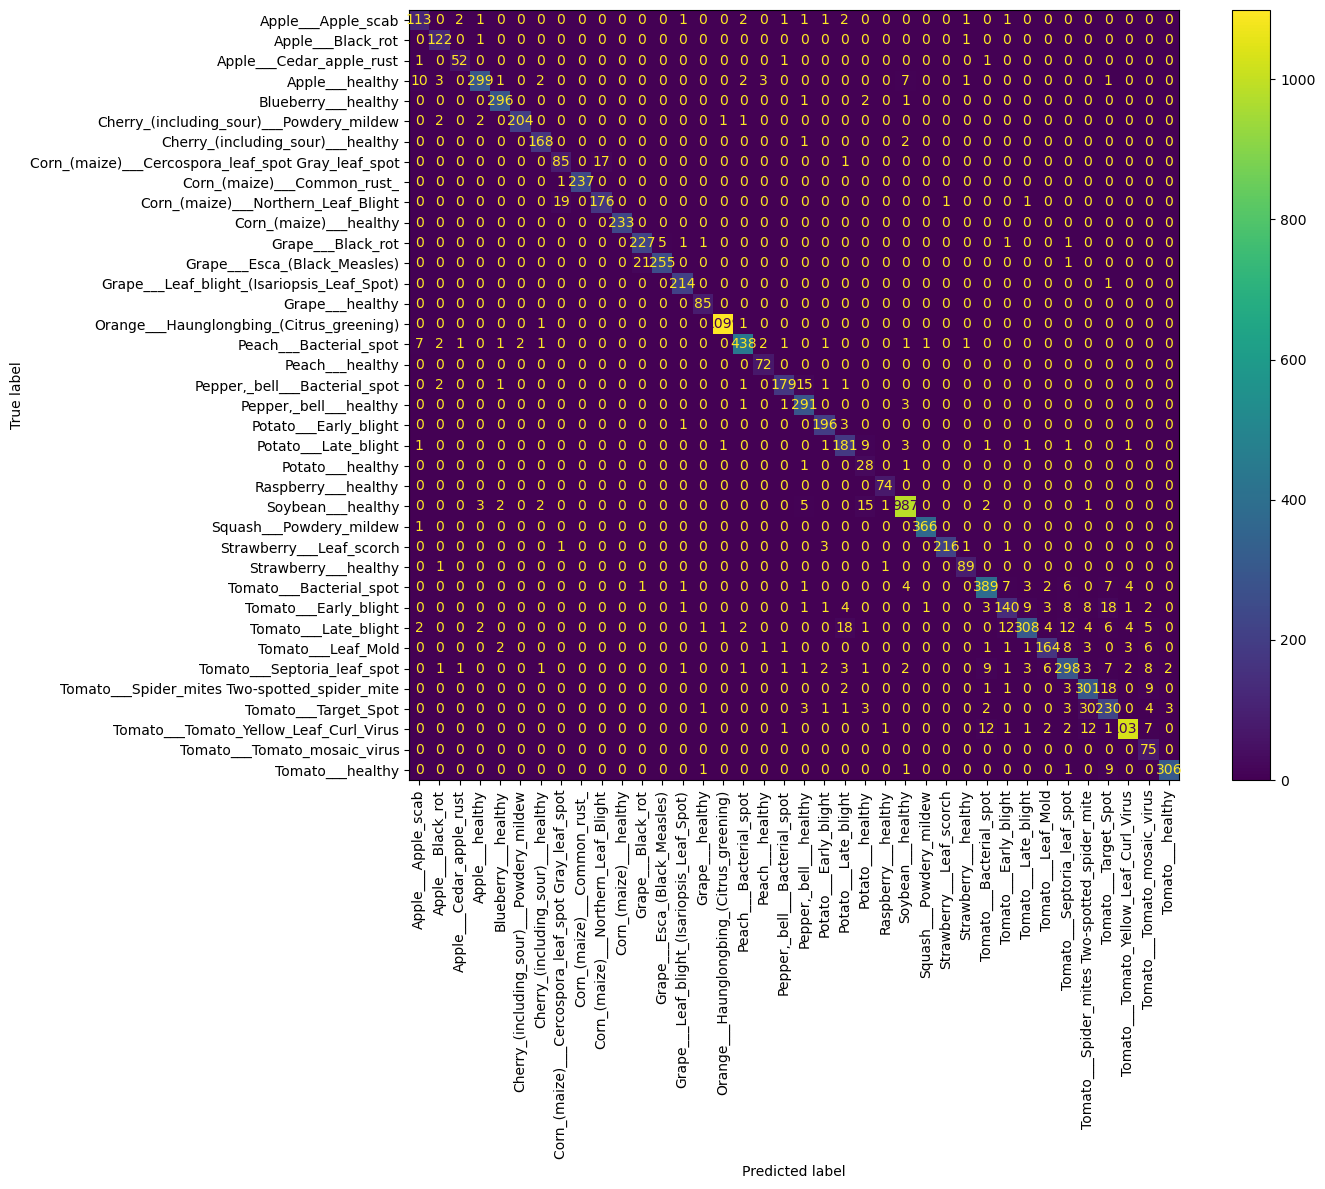

In [22]:
from sklearn.metrics import classification_report

print(f"Valor final accuracy en set de validación: {metrics_alexnet_fe.get_latest('eval_accuracy'):.3f}. Mejor valor: {np.max(metrics_alexnet_fe.get_all('eval_accuracy')):.3f}.")
metrics_alexnet_fe.plot_metrics(["train_accuracy", "eval_accuracy"])

print(f"Valor final F1 en set de validación: {metrics_alexnet_fe.get_latest('eval_f1'):.2f}")
metrics_alexnet_fe.plot_metrics(["train_f1", "eval_f1"])

metrics_alexnet_fe.plot_metrics(["train_loss", "eval_loss"])

print(classification_report(alexnet_fe_eval_y, alexnet_fe_eval_y_pred, target_names=idx_to_class.values()))

plot_cm(alexnet_fe_eval_y, alexnet_fe_eval_y_pred)

#### Modelo AlexNet - prueba 2

Ajustamos el modelo a nuestro problema por resolver, reemplazando todas las capas FC

In [23]:
# Load the pre-trained AlexNet model
model_alexnet_fe_2 = models.alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)

for param in model_alexnet_fe_2.parameters():
    param.requires_grad = False

num_in_class_ftrs = model_alexnet_fe_2.classifier[1].in_features # 256 * 6 * 6 para AlexNet
model_alexnet_fe_2.classifier  = nn.Sequential(
            nn.Dropout(),
            nn.Linear(num_in_class_ftrs, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, dset_classes_number),
)

In [24]:
# Verificamos la arquitectura del modelo luego de los cambios
# La diferencia se observa en la última capa que ahora tiene el número de clases del dataset
# Si bien no se observan cambios de arquitectura, todas las capas de clasificación estan re-inicializadas.
torchinfo.summary(model_alexnet_fe_2, input_size=(batch_size, 3, *img_size))

Layer (type:depth-idx)                   Output Shape              Param #
AlexNet                                  [128, 38]                 --
├─Sequential: 1-1                        [128, 256, 6, 6]          --
│    └─Conv2d: 2-1                       [128, 64, 55, 55]         (23,296)
│    └─ReLU: 2-2                         [128, 64, 55, 55]         --
│    └─MaxPool2d: 2-3                    [128, 64, 27, 27]         --
│    └─Conv2d: 2-4                       [128, 192, 27, 27]        (307,392)
│    └─ReLU: 2-5                         [128, 192, 27, 27]        --
│    └─MaxPool2d: 2-6                    [128, 192, 13, 13]        --
│    └─Conv2d: 2-7                       [128, 384, 13, 13]        (663,936)
│    └─ReLU: 2-8                         [128, 384, 13, 13]        --
│    └─Conv2d: 2-9                       [128, 256, 13, 13]        (884,992)
│    └─ReLU: 2-10                        [128, 256, 13, 13]        --
│    └─Conv2d: 2-11                      [128, 256, 13, 13

In [25]:
dataloader = { 'train': train_dataloader, 'val': val_dataloader }
steps_per_epoch = len(train_dataloader)

# Utilizamos mismas configuraciones de optimizador, criterio y scheduler

# Definimos optimizer y la función de pérdida
optimizer = torch.optim.Adam(model_alexnet_fe_2.parameters(), lr=0.001, weight_decay = 0.001)  
criterion = torch.nn.CrossEntropyLoss() # Adecuada para problemas de clasificación multiclase
# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=steps_per_epoch, T_mult=2, eta_min=1e-5)

In [26]:
model_name = "best_AlexNet_fe_2.pt"
metrics_alexnet_fe_2, alexnet_fe_2_eval_y, alexnet_fe_2_eval_y_pred = fit(model_alexnet_fe_2, dataloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, 
                                                                    epochs=15, patience=5, patience_factor=0.01, model_file=model_name)
# Al finalizar, cargo el mejor modelo
model_alexnet_fe_2.load_state_dict(torch.load(model_name))

val_loss 0.28287 val_acc 0.90710: 100%|██████████| 85/85 [00:16<00:00,  5.17it/s]


Epoch 1/15 loss 1.08325 val_loss 0.28287 acc 0.68594 val_acc 0.90710


val_loss 0.25807 val_acc 0.91400: 100%|██████████| 85/85 [00:16<00:00,  5.05it/s]


Epoch 2/15 loss 0.68535 val_loss 0.25807 acc 0.78225 val_acc 0.91400
	Info - Current epochs without validation metric improvement 1. 4 remaining before stopping.


val_loss 0.18832 val_acc 0.93840: 100%|██████████| 85/85 [00:16<00:00,  5.03it/s]


...

val_loss 0.15937 val_acc 0.94789: 100%|██████████| 85/85 [00:20<00:00,  4.14it/s]


Epoch 11/15 loss 0.40640 val_loss 0.15937 acc 0.86987 val_acc 0.94789
	Info - Current epochs without validation metric improvement 4. 1 remaining before stopping.


val_loss 0.14201 val_acc 0.95360: 100%|██████████| 85/85 [00:28<00:00,  2.96it/s]


Epoch 12/15 loss 0.35436 val_loss 0.14201 acc 0.88506 val_acc 0.95360
	Info - Training interrupted due to early stopping condition.


<All keys matched successfully>

Si bien hay una leve mejoría, llegando a un accuracy de 0.95 aprox, sigue quedando por debajo del modelo base.  
Probamos disminuyendo aun mas el LR, a 0.0001

In [27]:
# Load the pre-trained AlexNet model
model_alexnet_fe_2 = models.alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)

for param in model_alexnet_fe_2.parameters():
    param.requires_grad = False

num_in_class_ftrs = model_alexnet_fe_2.classifier[1].in_features # 256 * 6 * 6 para AlexNet
model_alexnet_fe_2.classifier  = nn.Sequential(
            nn.Dropout(),
            nn.Linear(num_in_class_ftrs, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, dset_classes_number),
)

In [28]:
dataloader = { 'train': train_dataloader, 'val': val_dataloader }
steps_per_epoch = len(train_dataloader)

# Utilizamos mismas configuraciones de criterio y scheduler, modificando el LR del optimizador

# Definimos optimizer y la función de pérdida
optimizer = torch.optim.Adam(model_alexnet_fe_2.parameters(), lr=0.0001, weight_decay = 0.001)  
criterion = torch.nn.CrossEntropyLoss() # Adecuada para problemas de clasificación multiclase
# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=steps_per_epoch, T_mult=2, eta_min=1e-5)

In [29]:
model_name = "best_AlexNet_fe_2.pt"
metrics_alexnet_fe_2, alexnet_fe_2_eval_y, alexnet_fe_2_eval_y_pred = fit(model_alexnet_fe_2, dataloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, 
                                                                    epochs=15, patience=5, patience_factor=0.01, model_file=model_name)
# Al finalizar, cargo el mejor modelo
model_alexnet_fe_2.load_state_dict(torch.load(model_name))

val_loss 0.25955 val_acc 0.91750: 100%|██████████| 85/85 [00:28<00:00,  2.99it/s]


Epoch 1/15 loss 0.89059 val_loss 0.25955 acc 0.74622 val_acc 0.91750


val_loss 0.17596 val_acc 0.94347: 100%|██████████| 85/85 [00:16<00:00,  5.18it/s]


Epoch 2/15 loss 0.40273 val_loss 0.17596 acc 0.87202 val_acc 0.94347


val_loss 0.14939 val_acc 0.95120: 100%|██████████| 85/85 [00:16<00:00,  5.02it/s]


...

val_loss 0.12240 val_acc 0.95728: 100%|██████████| 85/85 [00:16<00:00,  5.14it/s]


Epoch 10/15 loss 0.20724 val_loss 0.12240 acc 0.93088 val_acc 0.95728
	Info - Current epochs without validation metric improvement 4. 1 remaining before stopping.


val_loss 0.09749 val_acc 0.96750: 100%|██████████| 85/85 [00:16<00:00,  5.04it/s]


Epoch 11/15 loss 0.17866 val_loss 0.09749 acc 0.94104 val_acc 0.96750
	Info - Training interrupted due to early stopping condition.


<All keys matched successfully>

Observamos una leve mejora, superando por poco al modelo base.

#### Evaluación del Modelo AlexNet con Feature Extraction reemplazando todas las capas de clasificación
  * Accuracy
  * F1 Score
  * Costo (Loss)
  * Classification report
  * Matriz de confusión


Valor final accuracy en set de validación: 0.967. Mejor valor: 0.967.


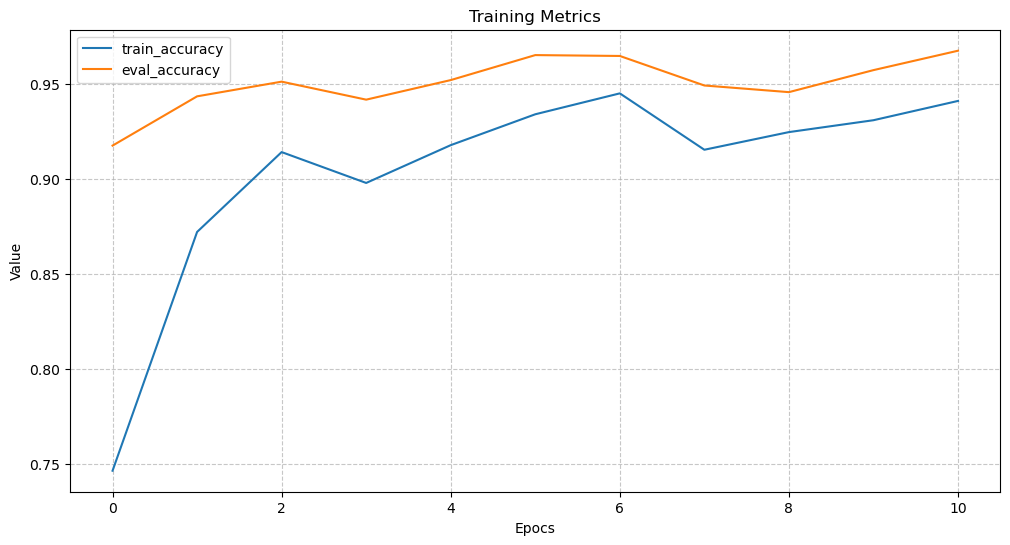

Valor final F1 en set de validación: 0.96


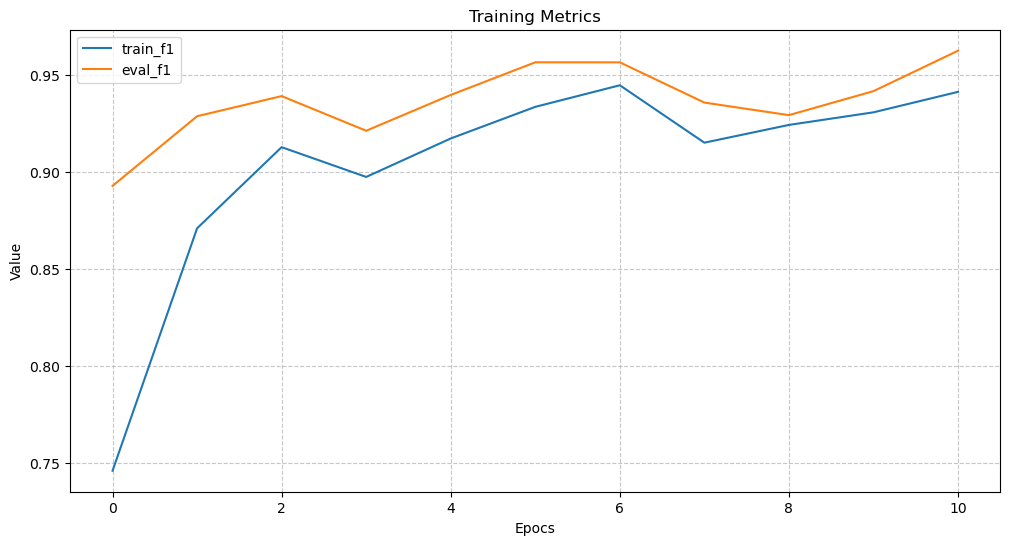

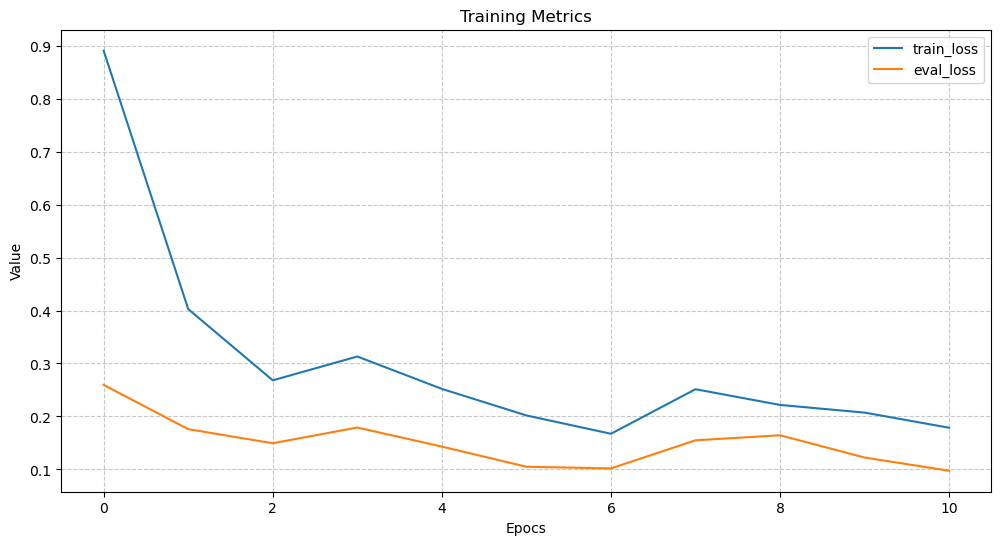

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.85      0.99      0.92       126
                                 Apple___Black_rot       0.93      1.00      0.96       124
                          Apple___Cedar_apple_rust       1.00      0.98      0.99        55
                                   Apple___healthy       0.99      0.92      0.95       329
                               Blueberry___healthy       0.99      1.00      0.99       300
          Cherry_(including_sour)___Powdery_mildew       0.98      0.99      0.99       210
                 Cherry_(including_sour)___healthy       0.97      1.00      0.99       171
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.85      0.88       103
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       238
               Corn_(maize)___Northern_Leaf_Blight       0.93      0.94      0.

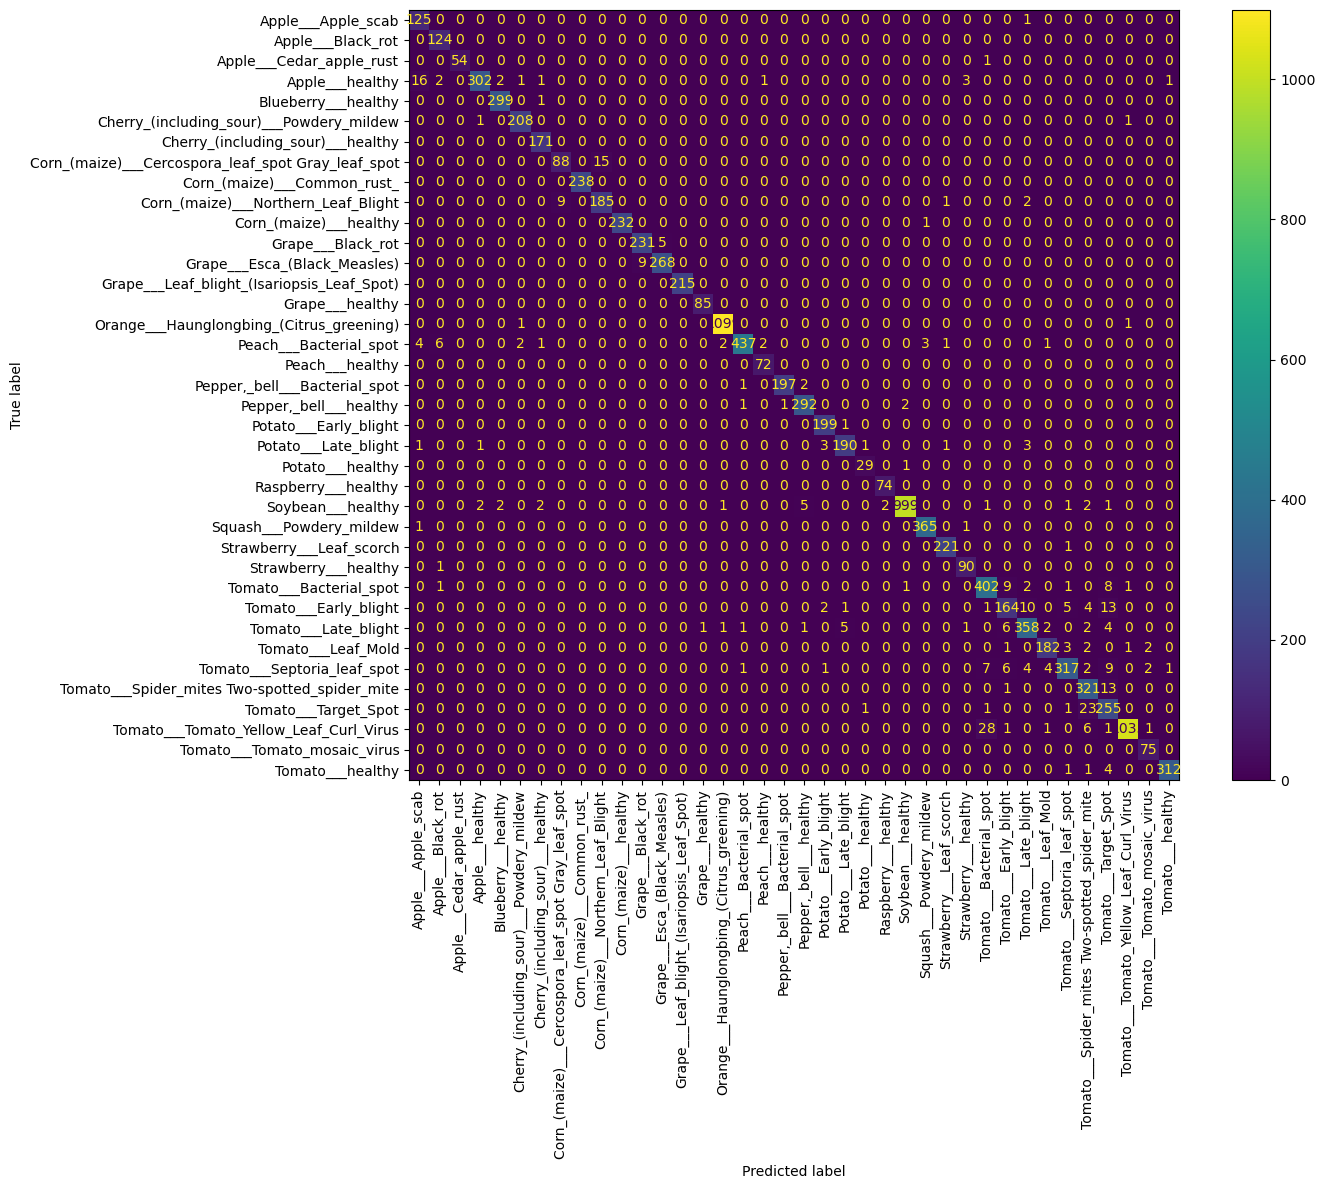

In [30]:
from sklearn.metrics import classification_report

print(f"Valor final accuracy en set de validación: {metrics_alexnet_fe_2.get_latest('eval_accuracy'):.3f}. Mejor valor: {np.max(metrics_alexnet_fe_2.get_all('eval_accuracy')):.3f}.")
metrics_alexnet_fe_2.plot_metrics(["train_accuracy", "eval_accuracy"])

print(f"Valor final F1 en set de validación: {metrics_alexnet_fe_2.get_latest('eval_f1'):.2f}")
metrics_alexnet_fe_2.plot_metrics(["train_f1", "eval_f1"])

metrics_alexnet_fe_2.plot_metrics(["train_loss", "eval_loss"])

print(classification_report(alexnet_fe_2_eval_y, alexnet_fe_2_eval_y_pred, target_names=idx_to_class.values()))

plot_cm(alexnet_fe_2_eval_y, alexnet_fe_2_eval_y_pred)

#### Modelo AlexNet - prueba 3

A partir del mejor resultado (prueba 2), realizamos un fine tuning sobre todo el modelo AlexNet (sin congelar capas).

In [31]:
# Load the pre-trained AlexNet model
model_alexnet_ft = models.alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)

num_in_class_ftrs = model_alexnet_ft.classifier[1].in_features # 256 * 6 * 6 para AlexNet
model_alexnet_ft.classifier  = nn.Sequential(
            nn.Dropout(),
            nn.Linear(num_in_class_ftrs, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, dset_classes_number),
)

In [32]:
dataloader = { 'train': train_dataloader, 'val': val_dataloader }
steps_per_epoch = len(train_dataloader)

# Utilizamos mismas configuraciones de optimizador, criterio y scheduler

# Definimos optimizer y la función de pérdida
optimizer = torch.optim.Adam(model_alexnet_ft.parameters(), lr=0.0001, weight_decay = 0.001)  
criterion = torch.nn.CrossEntropyLoss() # Adecuada para problemas de clasificación multiclase
# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=steps_per_epoch, T_mult=2, eta_min=1e-5)

In [33]:
model_name = "best_AlexNet_ft.pt"
metrics_alexnet_ft, alexnet_ft_eval_y, alexnet_ft_eval_y_pred = fit(model_alexnet_ft, dataloader, criterion=criterion, optimizer=optimizer, scheduler=scheduler, 
                                                                    epochs=15, patience=5, patience_factor=0.01, model_file=model_name)
# Al finalizar, cargo el mejor modelo
model_alexnet_ft.load_state_dict(torch.load(model_name))

val_loss 0.11843 val_acc 0.96225: 100%|██████████| 85/85 [00:16<00:00,  5.08it/s]


Epoch 1/15 loss 0.60098 val_loss 0.11843 acc 0.82319 val_acc 0.96225


val_loss 0.08827 val_acc 0.97137: 100%|██████████| 85/85 [00:15<00:00,  5.51it/s]


Epoch 2/15 loss 0.21540 val_loss 0.08827 acc 0.93070 val_acc 0.97137
	Info - Current epochs without validation metric improvement 1. 4 remaining before stopping.


val_loss 0.05867 val_acc 0.98011: 100%|██████████| 85/85 [00:27<00:00,  3.07it/s]


...

val_loss 0.03254 val_acc 0.98978: 100%|██████████| 85/85 [00:15<00:00,  5.34it/s]


Epoch 7/15 loss 0.03793 val_loss 0.03254 acc 0.98696 val_acc 0.98978
	Info - Current epochs without validation metric improvement 4. 1 remaining before stopping.


val_loss 0.10589 val_acc 0.96612: 100%|██████████| 85/85 [00:16<00:00,  5.07it/s]


Epoch 8/15 loss 0.10543 val_loss 0.10589 acc 0.96504 val_acc 0.96612
	Info - Training interrupted due to early stopping condition.


<All keys matched successfully>

En este caso se observa una mejora importante respecto a las pruebas anteriores, superando al modelo base y obteniendo un accuracy muy alto (0.99 aprox) en menos de 10 épocas.

#### Evaluación del Modelo AlexNet con Fine Tuning reemplazando todas las capas de clasificación
  * Accuracy
  * F1 Score
  * Costo (Loss)
  * Classification report
  * Matriz de confusión


Valor final accuracy en set de validación: 0.966. Mejor valor: 0.990.


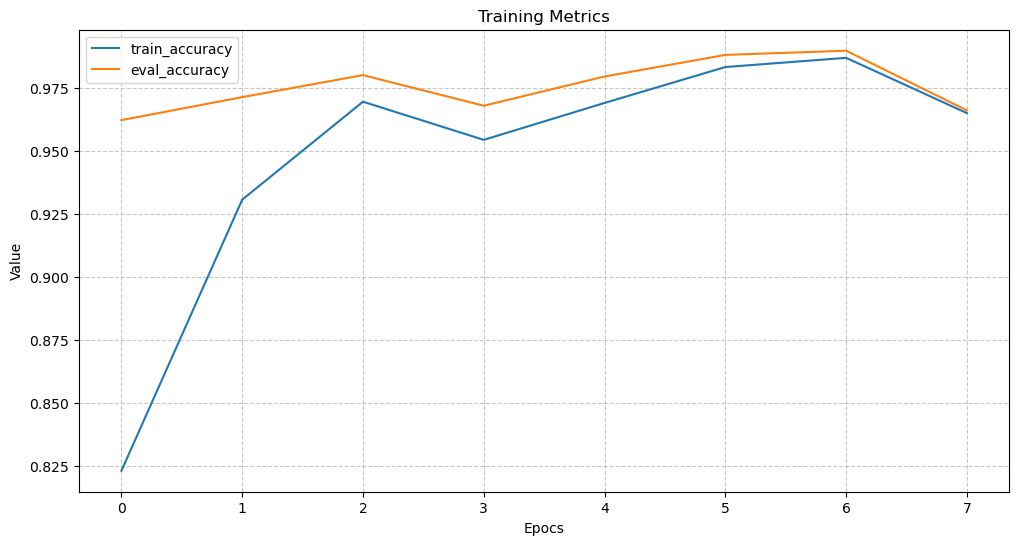

Valor final F1 en set de validación: 0.96


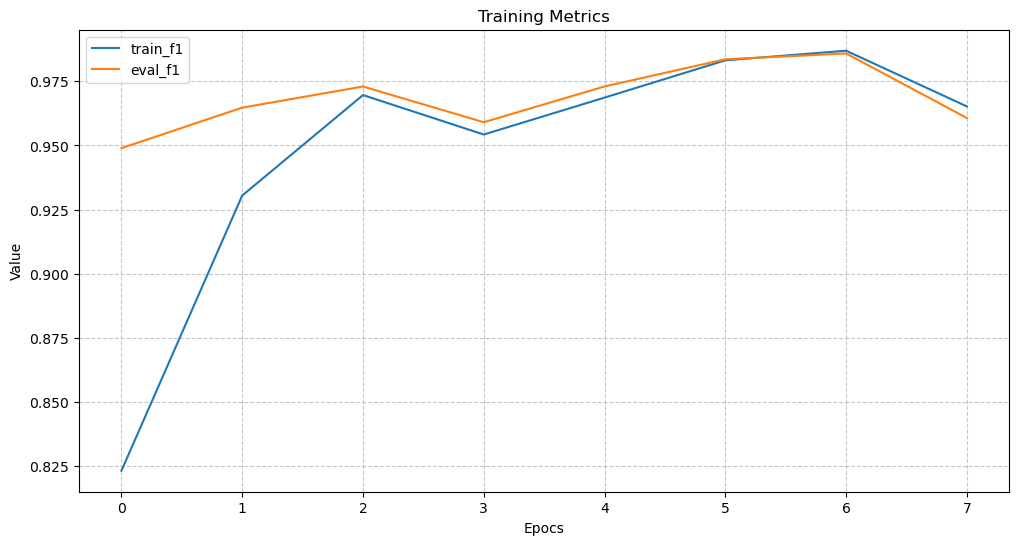

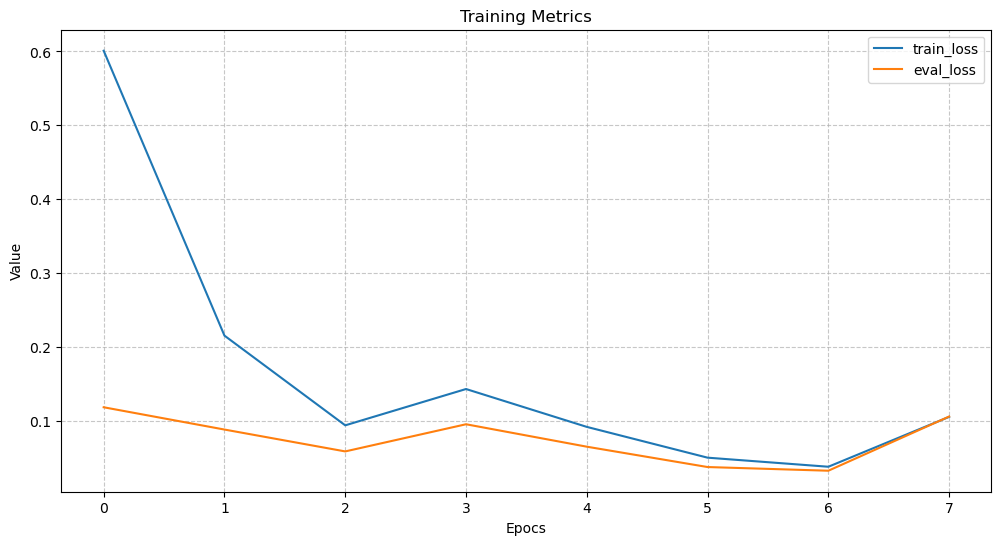

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.98      0.99       126
                                 Apple___Black_rot       1.00      1.00      1.00       124
                          Apple___Cedar_apple_rust       1.00      1.00      1.00        55
                                   Apple___healthy       1.00      0.99      0.99       329
                               Blueberry___healthy       1.00      1.00      1.00       300
          Cherry_(including_sour)___Powdery_mildew       1.00      1.00      1.00       210
                 Cherry_(including_sour)___healthy       1.00      1.00      1.00       171
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.85      0.83      0.84       103
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       238
               Corn_(maize)___Northern_Leaf_Blight       0.92      0.93      0.

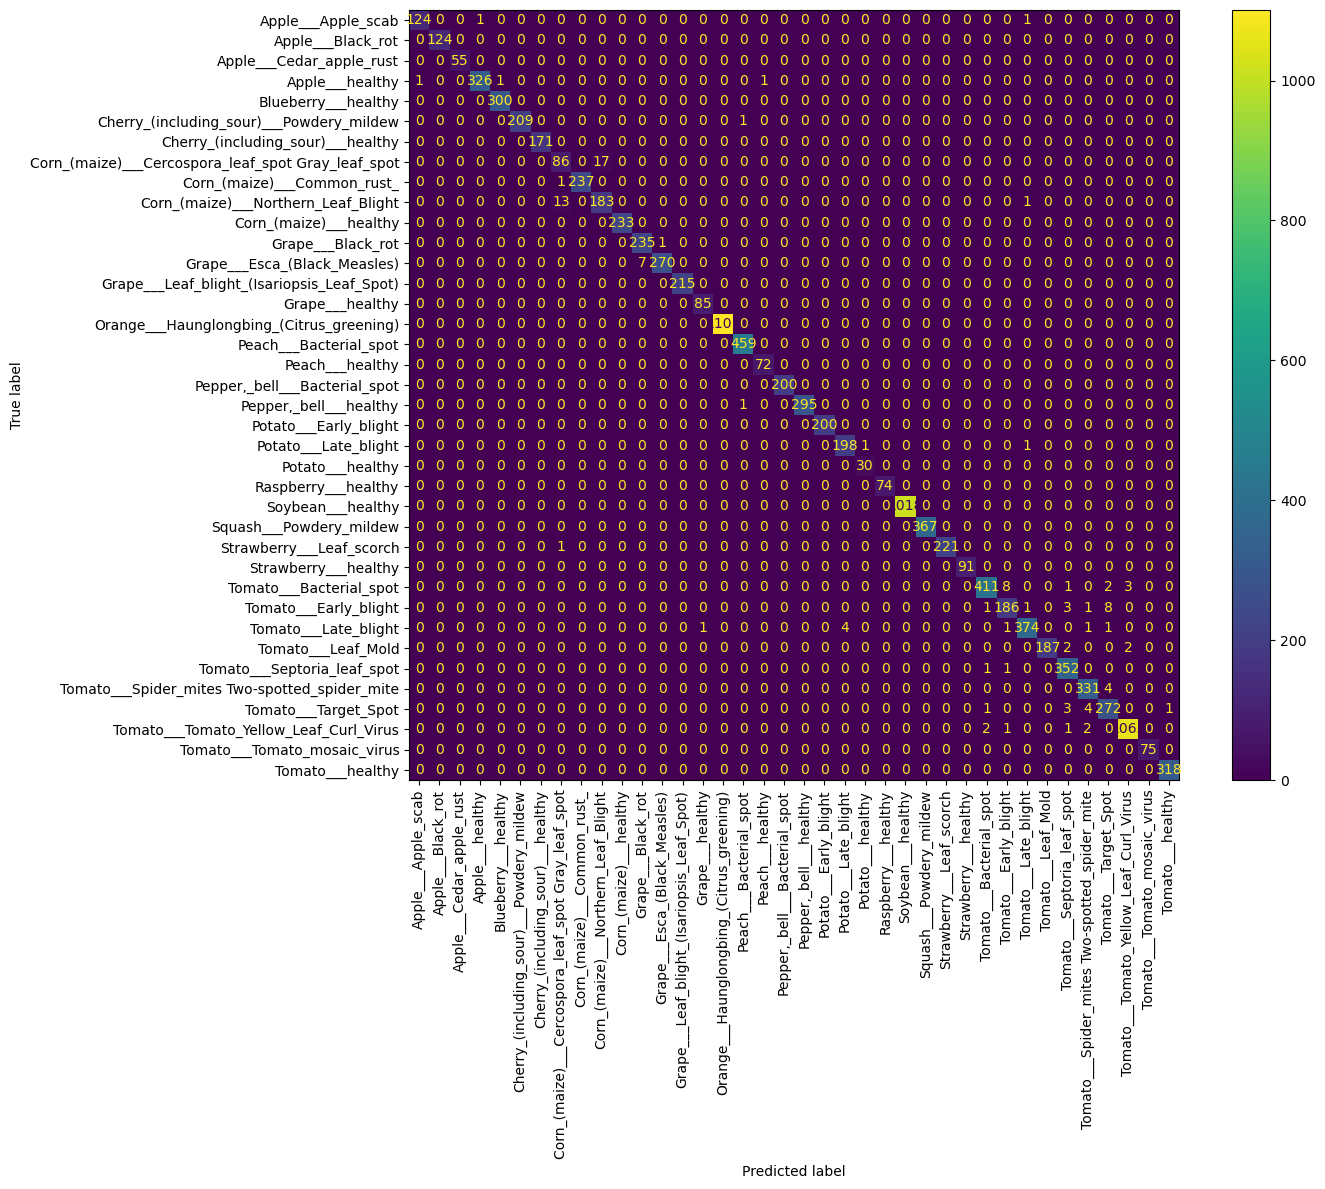

In [34]:
from sklearn.metrics import classification_report

print(f"Valor final accuracy en set de validación: {metrics_alexnet_ft.get_latest('eval_accuracy'):.3f}. Mejor valor: {np.max(metrics_alexnet_ft.get_all('eval_accuracy')):.3f}.")
metrics_alexnet_ft.plot_metrics(["train_accuracy", "eval_accuracy"])

print(f"Valor final F1 en set de validación: {metrics_alexnet_ft.get_latest('eval_f1'):.2f}")
metrics_alexnet_ft.plot_metrics(["train_f1", "eval_f1"])

metrics_alexnet_ft.plot_metrics(["train_loss", "eval_loss"])

print(classification_report(alexnet_ft_eval_y, alexnet_ft_eval_y_pred, target_names=idx_to_class.values()))

plot_cm(alexnet_ft_eval_y, alexnet_ft_eval_y_pred)

#### Visualización y prueba del modelo sobre imágenes de test

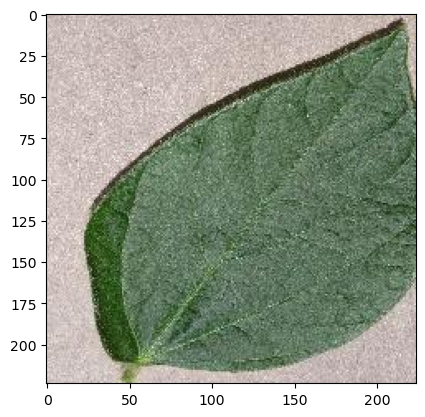

Predicted label: 24 (Soybean___healthy).
Real label: 24 (Soybean___healthy)


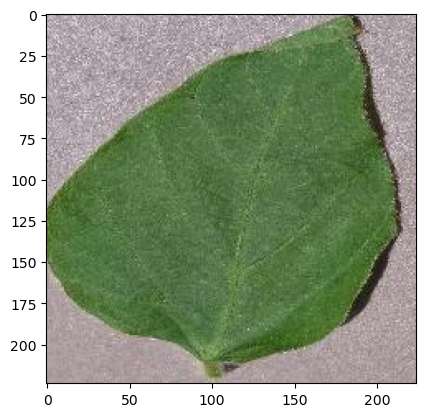

Predicted label: 24 (Soybean___healthy).
Real label: 24 (Soybean___healthy)


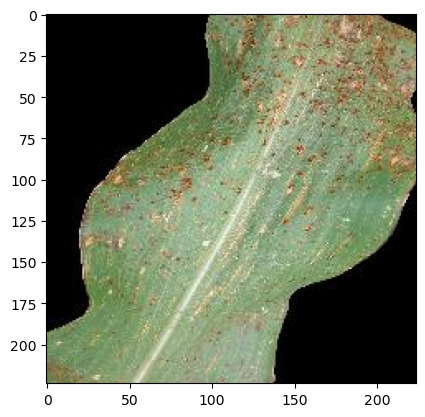

Predicted label: 8 (Corn_(maize)___Common_rust_).
Real label: 8 (Corn_(maize)___Common_rust_)


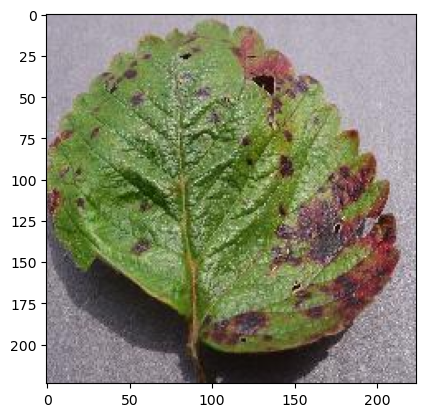

Predicted label: 26 (Strawberry___Leaf_scorch).
Real label: 26 (Strawberry___Leaf_scorch)


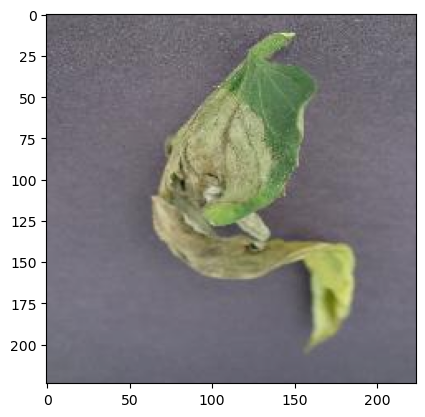

Predicted label: 30 (Tomato___Late_blight).
Real label: 30 (Tomato___Late_blight)


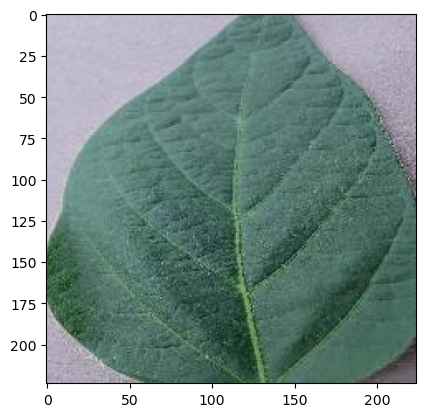

Predicted label: 24 (Soybean___healthy).
Real label: 24 (Soybean___healthy)


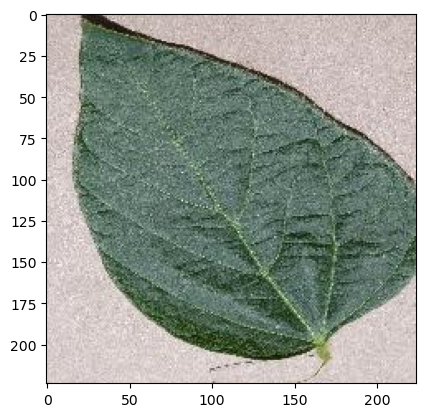

Predicted label: 24 (Soybean___healthy).
Real label: 24 (Soybean___healthy)


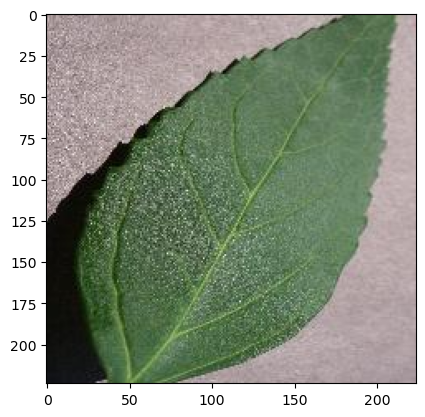

Predicted label: 6 (Cherry_(including_sour)___healthy).
Real label: 6 (Cherry_(including_sour)___healthy)


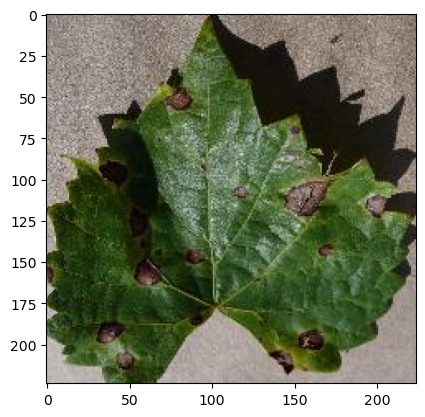

Predicted label: 11 (Grape___Black_rot).
Real label: 11 (Grape___Black_rot)


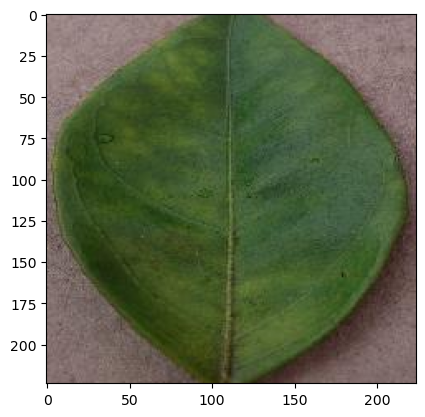

Predicted label: 15 (Orange___Haunglongbing_(Citrus_greening)).
Real label: 15 (Orange___Haunglongbing_(Citrus_greening))


In [35]:
for _ in range(10):
    test_features, test_labels = next(iter(test_dataloader))
    img_test_idx = torch.randint(len(test_features), (1,))
    img_test = test_features[img_test_idx]
    label_test = test_labels[img_test_idx]
    label_test_pred = np.argmax(model_alexnet_ft(img_test.to(device)).detach().cpu().numpy())
    # ploteamos esa imagen
    img_test = img_test.squeeze().permute(1, 2, 0).numpy()
    img_test = (img_test * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
    img_test = np.clip(img_test, 0, 1) # Clip values to be between 0 and 1
    plt.imshow(img_test)
    plt.show()
    print(f"Predicted label: {label_test_pred} ({idx_to_class[label_test_pred.item()]}).\nReal label: {label_test.item()} ({idx_to_class[label_test.item()]})")

## Conclusiones

El modelo AlexNet, tiene una performance similar si realizamos feature extraction.  
Suponemos que esto se debe a que el entrenamiento fue realizado sobre diversos objetos, que difieren bastante a las hojas que componen nuestro dataset.  

En cambio, al realizar fine tuning, AlexNet logra mejorar las métricas, superando al modelo base, quedando muy cerca de un modelo perfecto.

Se observan algunas confusiones en la matriz, por ejemplo, Corn cercospora con Corn Northern (13 casos) y viceversa (17 casos).  
Verificando visualmente el tipo de hoja y enfermedad, se ven similitudes, lo que entendemos termina confundiendo levemente al modelo.